In [1]:
from google.colab import files

In [2]:
uploaded = files.upload()

Saving train.csv to train.csv


In [3]:
import pandas as pd

In [4]:
train = pd.read_csv('train.csv')

In [5]:
train_copy = train.copy()

In [6]:
train_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


In [7]:
train_copy.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [8]:
train_copy.duplicated().sum()

np.int64(0)

In [9]:
train_copy.isna().sum()

,0
date,0
store,0
item,0
sales,0


In [10]:
train_copy['date'] = pd.to_datetime(train_copy['date'])

In [11]:
train_copy.describe()

,date,store,item,sales
count,913000,913000.000000,913000.000000,913000.000000
mean,2015-07-02 11:59:59.999999744,5.500000,25.500000,52.250287
min,2013-01-01 00:00:00,1.000000,1.000000,0.000000
25%,2014-04-02 00:00:00,3.000000,13.000000,30.000000
50%,2015-07-02 12:00:00,5.500000,25.500000,47.000000
75%,2016-10-01 00:00:00,8.000000,38.000000,70.000000
max,2017-12-31 00:00:00,10.000000,50.000000,231.000000
std,NaN,2.872283,14.430878,28.801144


Добавляем столбы год, месяц, день

In [12]:
train_copy['day_of_week'] = train_copy['date'].dt.day_of_week
train_copy['month'] = train_copy['date'].dt.month
train_copy['year'] = train_copy['date'].dt.year
train_copy['year_month'] = train_copy['date'].dt.to_period('M')

Для тренировки отделяем последний год, после анализа сверим результат прогноза

In [13]:
train_2013_2016 = train_copy[train_copy['year']< 2017].copy()

In [14]:
train_2013_2016.describe()

,date,store,item,sales,day_of_week,month,year
count,730500,730500.000000,730500.00000,730500.000000,730500.000000,730500.000000,730500.000000
mean,2015-01-01 00:00:00.000000256,5.500000,25.50000,50.610229,3.000000,6.522930,2014.501027
min,2013-01-01 00:00:00,1.000000,1.00000,0.000000,0.000000,1.000000,2013.000000
25%,2014-01-01 00:00:00,3.000000,13.00000,29.000000,1.000000,4.000000,2014.000000
50%,2015-01-01 00:00:00,5.500000,25.50000,45.000000,3.000000,7.000000,2015.000000
75%,2016-01-01 00:00:00,8.000000,38.00000,67.000000,5.000000,10.000000,2016.000000
max,2016-12-31 00:00:00,10.000000,50.00000,214.000000,6.000000,12.000000,2016.000000
std,NaN,2.872283,14.43088,27.830964,1.998289,3.448706,1.118340


Проверим на аномальность в продажах

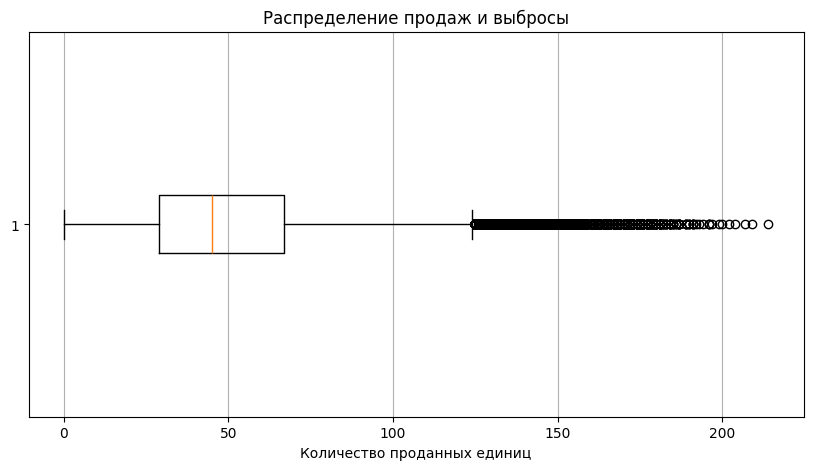

In [15]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
plt.figure(figsize=(10, 5))

plt.boxplot(train_2013_2016['sales'], vert=False)

plt.title('Распределение продаж и выбросы')
plt.xlabel('Количество проданных единиц')

plt.grid(axis='x')
plt.show()

В данных есть большое количество высоких значений sales, но пока неизвестно, являются ли они ошибками или нормальными пиками спроса.

In [16]:
train_2013_2016[train_2013_2016['sales']>180]

,date,store,item,sales,day_of_week,month,year,year_month
130953,2016-07-31,2,8,181,6,7,2016,2016-07
222203,2016-06-11,2,13,187,5,6,2016,2016-06
222224,2016-07-02,2,13,182,5,7,2016,2016-07
222225,2016-07-03,2,13,189,6,7,2016,2016-07
222246,2016-07-24,2,13,204,6,7,2016,2016-07
...,...,...,...,...,...,...,...,...
678753,2016-07-31,2,38,181,6,7,2016,2016-07
680579,2016-07-31,3,38,182,6,7,2016,2016-07
817472,2016-06-04,8,45,181,5,6,2016,2016-06
817515,2016-07-17,8,45,191,6,7,2016,2016-07


In [17]:
train_2013_2016[
    (train_2013_2016['store'] == 2) &
    (train_2013_2016['item'] == 13) &
    (train_2013_2016['date']>= '2016-07-20') &
    (train_2013_2016['date']<= '2016-07-28')
]

,date,store,item,sales,day_of_week,month,year,year_month
222242,2016-07-20,2,13,154,2,7,2016,2016-07
222243,2016-07-21,2,13,144,3,7,2016,2016-07
222244,2016-07-22,2,13,162,4,7,2016,2016-07
222245,2016-07-23,2,13,165,5,7,2016,2016-07
222246,2016-07-24,2,13,204,6,7,2016,2016-07
222247,2016-07-25,2,13,108,0,7,2016,2016-07
222248,2016-07-26,2,13,135,1,7,2016,2016-07
222249,2016-07-27,2,13,153,2,7,2016,2016-07
222250,2016-07-28,2,13,172,3,7,2016,2016-07


Экстимальные значения не выглядят аномальными

In [18]:
sales_by_year = train_2013_2016.groupby('year').agg(Количество_единиц = ('sales', 'sum')).reset_index()

In [19]:
sales_by_year.head()

,year,Количество_единиц
0,2013,7941243
1,2014,9135482
2,2015,9536887
3,2016,10357160


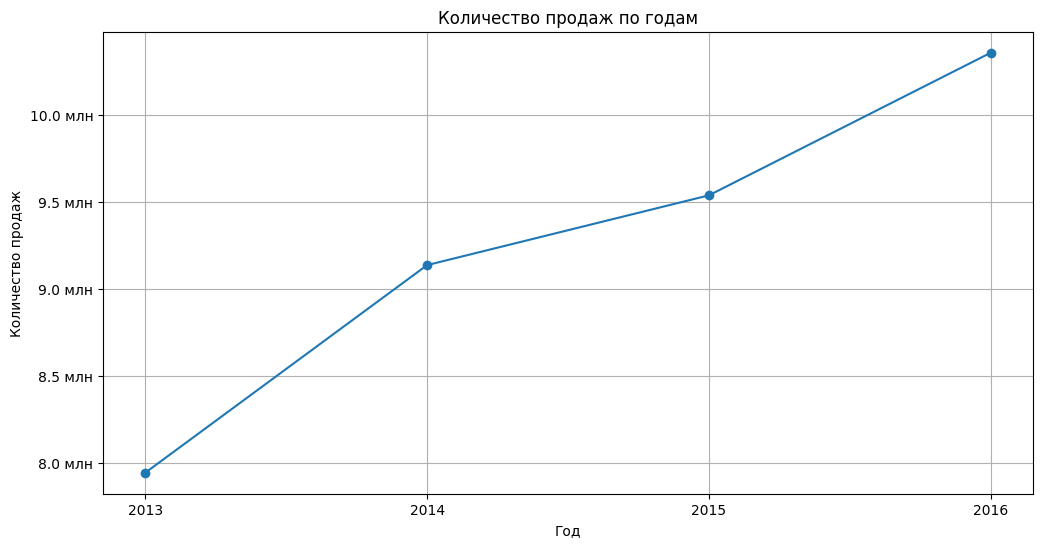

In [20]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(12, 6))
plt.plot(sales_by_year['year'].astype(str), sales_by_year['Количество_единиц'], marker='o')

plt.title('Количество продаж по годам')
plt.xlabel('Год')
plt.ylabel('Количество продаж')

plt.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x/1_000_000:.1f} млн' if x >= 1_000_000 else f'{x/1_000:.0f} тыс.'))

plt.grid()
plt.show()


In [21]:
sales_by_year_month = train_2013_2016.groupby('year_month').agg(Количество_единиц = ('sales', 'sum')).reset_index()

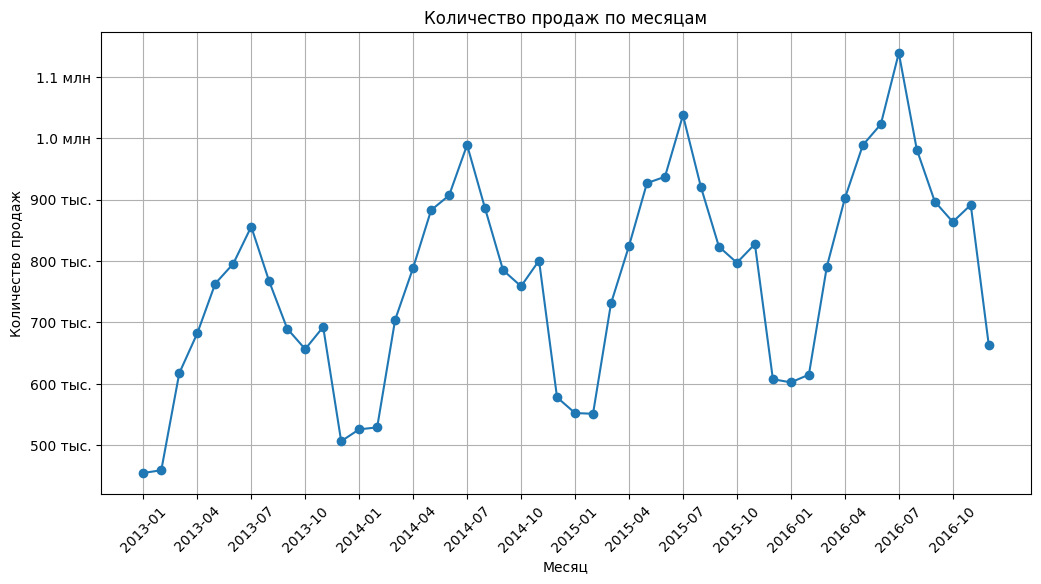

In [22]:

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(12, 6))
plt.plot(sales_by_year_month['year_month'].astype(str), sales_by_year_month['Количество_единиц'], marker='o')

plt.title('Количество продаж по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество продаж')

plt.grid()
plt.xticks(
    sales_by_year_month['year_month'].astype(str)[::3],
    rotation=45)

plt.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x/1_000_000:.1f} млн' if x >= 1_000_000 else f'{x/1_000:.0f} тыс.'))
plt.show()


In [23]:
sales_by_month = train_2013_2016.groupby('month').agg(Количество_единиц = ('sales', 'mean')).reset_index()

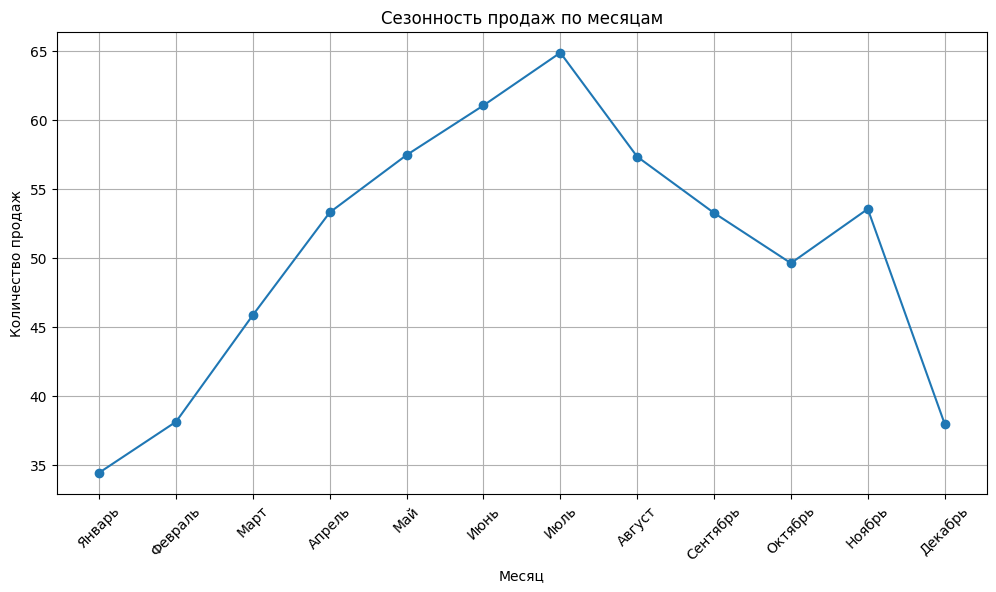

In [24]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(12, 6))
plt.plot(sales_by_month['month'], sales_by_month['Количество_единиц'], marker='o')

plt.title('Сезонность продаж по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество продаж')

plt.grid()
months_ru = [
    'Январь', 'Февраль', 'Март', 'Апрель',
    'Май', 'Июнь', 'Июль', 'Август',
    'Сентябрь', 'Октябрь', 'Ноябрь', 'Декабрь'
]

plt.xticks(range(1, 13), months_ru, rotation=45)
plt.show()


In [25]:
train_copy.head()

,date,store,item,sales,day_of_week,month,year,year_month
0,2013-01-01,1,1,13,1,1,2013,2013-01
1,2013-01-02,1,1,11,2,1,2013,2013-01
2,2013-01-03,1,1,14,3,1,2013,2013-01
3,2013-01-04,1,1,13,4,1,2013,2013-01
4,2013-01-05,1,1,10,5,1,2013,2013-01


In [26]:
sales_by_store = train_2013_2016.groupby('store').agg(Количество_единиц = ('sales', 'sum')).reset_index()

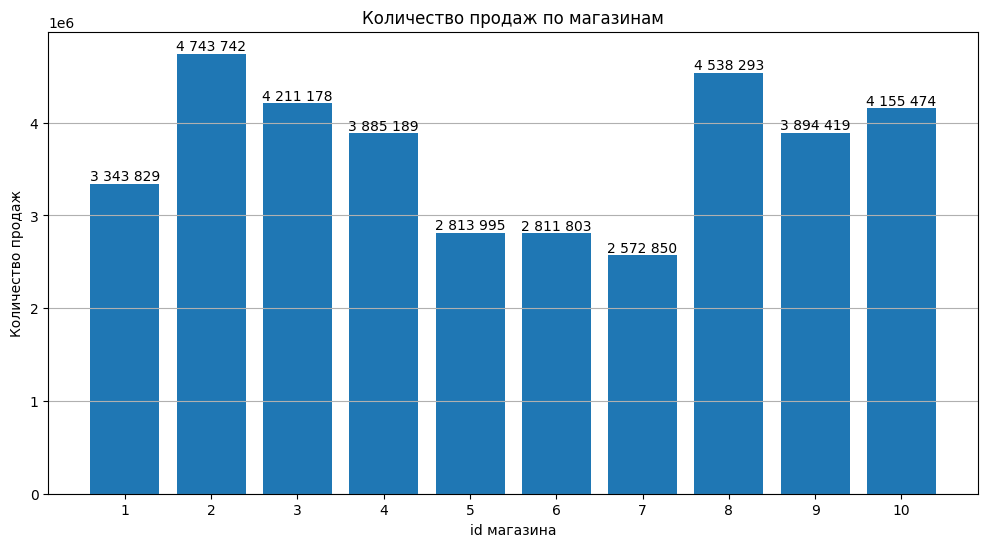

In [27]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
bars = plt.bar(
    sales_by_store['store'].astype(str),
    sales_by_store['Количество_единиц'])
plt.title('Количество продаж по магазинам')
plt.xlabel('id магазина')
plt.ylabel('Количество продаж')
plt.grid(axis='y')
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:,.0f}'.replace(',', ' '),
        ha='center',
        va='bottom'  )
plt.show()


In [28]:
sales_by_store_month = train_2013_2016.groupby(['store', 'year_month']).agg(Количество_единиц = ('sales', 'sum')).reset_index()

In [29]:
sales_by_store_month = sales_by_store_month.merge(sales_by_store[['store', 'Количество_единиц']], on='store', how='left')

In [30]:
sales_by_store_month = sales_by_store_month.rename(columns={'Количество_единиц_y': 'Количество_единиц_общее', 'Количество_единиц_x': 'Количество_единиц'})

In [31]:
sales_by_store_month

,store,year_month,Количество_единиц,Количество_единиц_общее
0,1,2013-01,41077,3343829
1,1,2013-02,41306,3343829
2,1,2013-03,55827,3343829
3,1,2013-04,61523,3343829
4,1,2013-05,69272,3343829
...,...,...,...,...
475,10,2016-08,110610,4155474
476,10,2016-09,100301,4155474
477,10,2016-10,97460,4155474
478,10,2016-11,100236,4155474


In [32]:
top_5_store_ids = sales_by_store_month.sort_values('Количество_единиц_общее', ascending=False).drop_duplicates('store').head()['store']

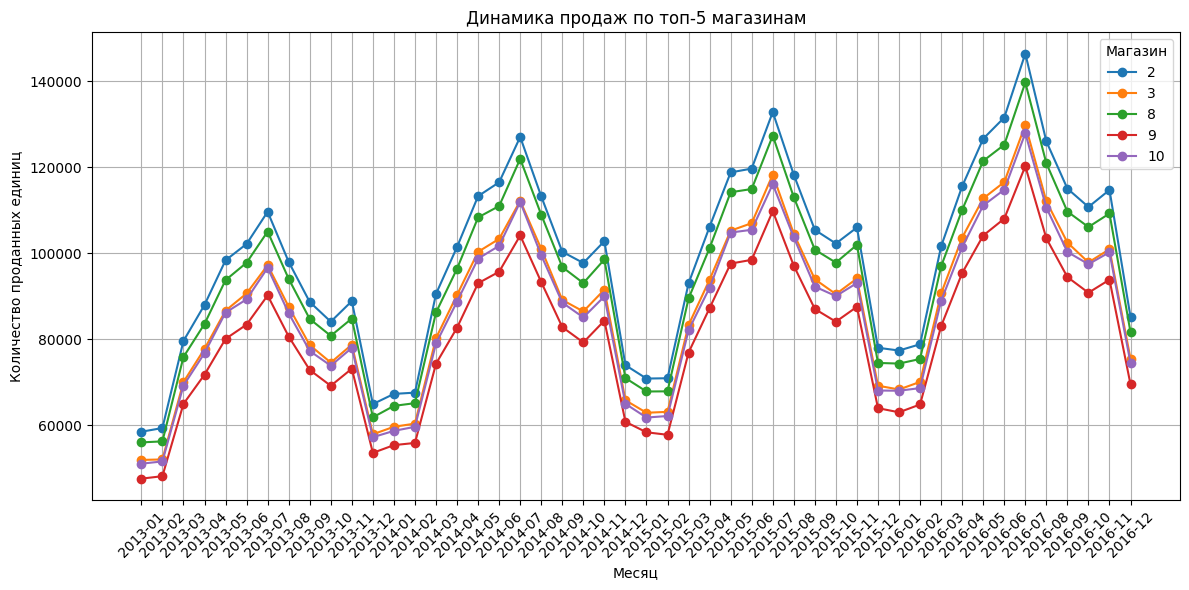

In [33]:
plt.figure(figsize=(12, 6))
for store, group in sales_by_store_month[sales_by_store_month['store'].isin(top_5_store_ids)].groupby('store'):
    plt.plot(
        group['year_month'].astype(str),
        group['Количество_единиц'],
        marker='o',
        label=store)
plt.title('Динамика продаж по топ-5 магазинам')
plt.xlabel('Месяц')
plt.ylabel('Количество проданных единиц')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Магазин')
plt.tight_layout()
plt.show()


In [34]:
bottom_5_store_ids = sales_by_store_month.sort_values('Количество_единиц_общее', ascending=True).drop_duplicates('store').head()['store']

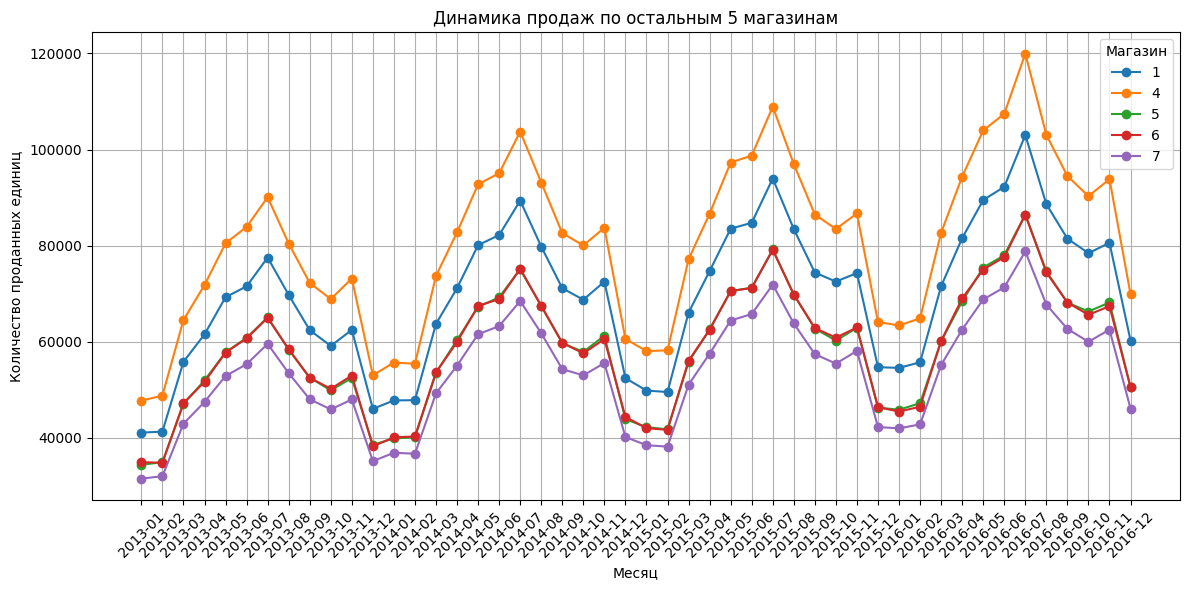

In [35]:
plt.figure(figsize=(12, 6))
for store, group in sales_by_store_month[sales_by_store_month['store'].isin(bottom_5_store_ids)].groupby('store'):
    plt.plot(
        group['year_month'].astype(str),
        group['Количество_единиц'],
        marker='o',
        label=store)
plt.title('Динамика продаж по остальным 5 магазинам')
plt.xlabel('Месяц')
plt.ylabel('Количество проданных единиц')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Магазин')
plt.tight_layout()
plt.show()


вывод: поведение магазинов довольно похоже, но масштабы продаж разные.

Проверим продажи по товарно

In [36]:
sales_by_item = train_2013_2016.groupby('item').agg(Количество_продаж = ('sales', 'sum')).reset_index()

Выручка по товарно за все время

In [37]:
sales_by_item.head()

,item,Количество_продаж
0,1,311231
1,2,829143
2,3,518285
3,4,312124
4,5,259423


In [38]:
sales_by_item_month = train_2013_2016.groupby(['item', 'year_month']).agg(Количество_продаж = ('sales', 'sum')).reset_index()

In [39]:
sales_by_item_month.head()

,item,year_month,Количество_продаж
0,1,2013-01,3794
1,1,2013-02,3863
2,1,2013-03,5190
3,1,2013-04,5783
4,1,2013-05,6298


In [40]:
sales_by_item_year = train_2013_2016.groupby(['item', 'year']).agg(Количество_продаж = ('sales', 'sum')).reset_index()

In [41]:
sales_by_item_year['Рост_год_к_году_%']= (sales_by_item_year.groupby('item')['Количество_продаж'].pct_change() *100)


In [42]:
sales_by_item_year

,item,year,Количество_продаж,Рост_год_к_году_%
0,1,2013,66723,NaN
1,1,2014,76777,15.068267
2,1,2015,80507,4.858226
3,1,2016,87224,8.343374
4,2,2013,178096,NaN
...,...,...,...,...
195,49,2016,115717,7.474761
196,50,2013,200490,NaN
197,50,2014,230733,15.084543
198,50,2015,240403,4.190991


In [43]:
sales_growth = sales_by_item_year[sales_by_item_year['year']>2013]

In [44]:
item_growth_check = sales_growth.groupby('item')['Рост_год_к_году_%'].apply(lambda x: (x>0).all()).reset_index()

In [45]:
sales_by_day_of_week = train_2013_2016.groupby('day_of_week').agg(Количество_продаж = ('sales', 'mean')).reset_index()

In [46]:
sales_by_day_of_week

,day_of_week,Количество_продаж
0,0,40.132548
1,1,46.734699
2,2,46.821675
3,3,50.040545
4,4,53.468182
5,5,56.791148
6,6,60.278933


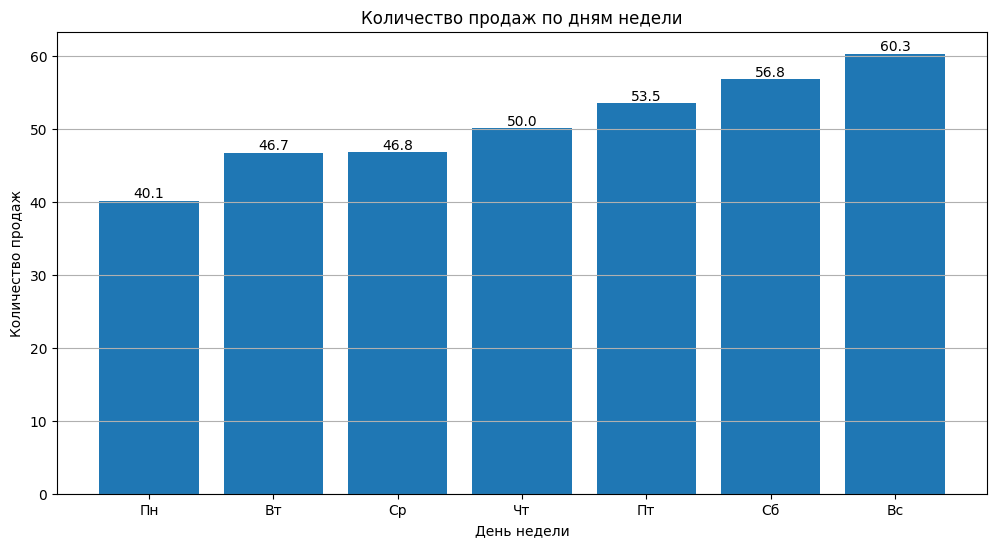

In [47]:
days_ru = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
bars = plt.bar(
    sales_by_day_of_week['day_of_week'],
    sales_by_day_of_week['Количество_продаж'])
plt.title('Количество продаж по дням недели')
plt.xlabel('День недели')
plt.ylabel('Количество продаж')
plt.bar_label(bars, fmt='%.1f')
plt.grid(axis='y')
plt.xticks(range(7), days_ru)

plt.show()



Прогноз продаж 2017 года вариант 1


In [48]:
baseline_2017_1 = train_2013_2016[train_2013_2016['year'] == 2016].copy()

In [49]:
baseline_2017_1 = pd.DataFrame({'data': pd.date_range('2017-01-01', '2017-12-31')})

In [50]:
store_item_pairs = (train_2013_2016[['store', 'item']].drop_duplicates().reset_index(drop=True))

In [51]:
baseline_2017_1 = baseline_2017_1.merge(store_item_pairs, how='cross')

In [52]:
baseline_2017_1['date_2016'] = baseline_2017_1['data'].apply(lambda x: x.replace(year=2016))

In [53]:
baseline_2017_1 = baseline_2017_1.merge(train_2013_2016[['date','store', 'item', 'sales']], left_on=['date_2016', 'store', 'item'], right_on=['date', 'store', 'item'], how='left')

In [54]:
baseline_2017_1 = baseline_2017_1.drop(columns='date')

In [226]:
baseline_2017_1 = baseline_2017_1.rename(columns={'sales':'Прогноз_baseline_1'})

In [234]:
baseline_2017_1.head()

,data,store,item,date_2016,Прогноз_baseline_1
0,2017-01-01,1,1,2016-01-01,21
1,2017-01-01,2,1,2016-01-01,31
2,2017-01-01,3,1,2016-01-01,23
3,2017-01-01,4,1,2016-01-01,17
4,2017-01-01,5,1,2016-01-01,10


Прогноз продаж 2017 года вариант 2

In [57]:
sales_by_store_item_year = train_2013_2016.groupby(['store','item', 'year']).agg(Количество_продаж = ('sales', 'sum')).reset_index()

In [58]:
sales_by_store_item_year['процент_роста']= (sales_by_store_item_year.groupby(['store','item'])['Количество_продаж'].pct_change() *100)


In [59]:
avg_growth_store_item = sales_by_store_item_year.groupby(['store', 'item']).agg(Средний_процент_роста = ('процент_роста', 'mean')).reset_index()

In [60]:
baseline_2017_2 = baseline_2017_1.copy()

In [61]:
baseline_2017_2 = baseline_2017_2.merge(avg_growth_store_item[['store', 'item', 'Средний_процент_роста']], on=['store','item'], how='left')

In [62]:
baseline_2017_2['Прогноз_продаж_baseline_2'] = (baseline_2017_2['Прогноз_продаж'] * (1+  baseline_2017_2['Средний_процент_роста'] /100))

In [235]:
baseline_2017_2.head()

,data,store,item,date_2016,Прогноз_baseline_2,Средний_процент_роста
0,2017-01-01,1,1,2016-01-01,23.044856,9.737410
1,2017-01-01,2,1,2016-01-01,33.915562,9.405038
2,2017-01-01,3,1,2016-01-01,25.170644,9.437583
3,2017-01-01,4,1,2016-01-01,18.542138,9.071398
4,2017-01-01,5,1,2016-01-01,10.897073,8.970730


ML обучение

In [65]:
ml_data = train_2013_2016.copy()

In [66]:
ml_data['Продажи_1_день_назад']= ml_data.groupby(['store', 'item'])['sales'].shift(1)
ml_data['Продажи_7_дней_назад']= ml_data.groupby(['store', 'item'])['sales'].shift(7)

In [67]:
ml_data['Продажи_28_дней_назад']= ml_data.groupby(['store', 'item'])['sales'].shift(28)

In [68]:
ml_data['Средние_продажи_7_дней'] = ml_data.groupby(['store', 'item'])['sales'].transform(lambda x: x.shift(1).rolling(7).mean())


In [69]:
ml_data['Средние_продажи_28_дней'] = ml_data.groupby(['store', 'item'])['sales'].transform(lambda x: x.shift(1).rolling(28).mean())

In [70]:
ml_data_clean = ml_data.dropna(how='any').copy()

In [71]:
y = ml_data_clean['sales']

In [72]:
x = ml_data_clean[[
    'store', 'item', 'day_of_week', 'month', 'year', 'Продажи_1_день_назад', 'Продажи_7_дней_назад', 'Продажи_28_дней_назад', 'Средние_продажи_7_дней', 'Средние_продажи_28_дней'
]]

In [73]:
train_mask = ml_data_clean['year'] < 2016
valid_mask = ml_data_clean['year'] == 2016

In [74]:
x_train = x[train_mask]
x_valid = x[valid_mask]

y_train = y[train_mask]
y_valid = y[valid_mask]


In [75]:
print(x_train.shape)
print(x_valid.shape)
print(y_train.shape)
print(y_valid.shape)

(533500, 10)
(183000, 10)
(533500,)
(183000,)


In [76]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.4 MB/s eta 0:00:00


In [77]:
from catboost import CatBoostRegressor


In [78]:
model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    loss_function='RMSE',
    verbose=100
)

In [79]:
model.fit(
    x_train,
    y_train,
    cat_features=['store', 'item'],
    eval_set=(x_valid, y_valid)
)

0:	learn: 25.5122288	test: 30.0550626	best: 30.0550626 (0)	total: 571ms	remaining: 4m 44s
100:	learn: 7.4469820	test: 8.1682709	best: 8.1682709 (100)	total: 1m 24s	remaining: 5m 35s
200:	learn: 7.3185040	test: 8.0138539	best: 8.0138539 (200)	total: 2m 16s	remaining: 3m 22s
300:	learn: 7.2530553	test: 7.9792693	best: 7.9792693 (300)	total: 3m 21s	remaining: 2m 13s
400:	learn: 7.2054715	test: 7.9733770	best: 7.9712224 (369)	total: 4m 16s	remaining: 1m 3s
499:	learn: 7.1710564	test: 7.9809240	best: 7.9712224 (369)	total: 5m 2s	remaining: 0us

bestTest = 7.971222367
bestIteration = 369

Shrink model to first 370 iterations.


CatBoostRegressor(depth=8, iterations=500, learning_rate=0.05, loss_function='RMSE', verbose=100)

In [80]:
y_pred = model.predict(x_valid)

In [81]:
comparison = pd.DataFrame({
    'Факт': y_valid.values,
    'Прогноз': y_pred
})
comparison.head(10)

,Факт,Прогноз
0,21,14.804136
1,13,15.455153
2,12,16.389868
3,12,10.669303
4,12,12.415301
5,16,12.415159
6,12,13.588921
7,12,14.323617
8,16,14.865152
9,26,15.971620


In [82]:
from sklearn.metrics import mean_absolute_error

mae_ml = mean_absolute_error(y_valid, y_pred)

mae_ml

6.092044526945568

In [83]:
from sklearn.metrics import root_mean_squared_error

rmse_ml = root_mean_squared_error(y_valid, y_pred)

rmse_ml

7.9712223665957005

In [84]:
mask_nonzero = y_valid != 0

mape_ml = (
    abs(
        (y_valid[mask_nonzero] - y_pred[mask_nonzero])
        / y_valid[mask_nonzero]
    ).mean()
    * 100
)

mape_ml

np.float64(12.721517000862287)

Сравним прогноз ML и прсотого прогназировани япо 2016 году

In [85]:
baseline_source_2016 = pd.DataFrame({'date':pd.date_range('2016-01-01', '2016-12-31')})

In [86]:
baseline_source_2016 = baseline_source_2016.merge(store_item_pairs, how='cross')

In [87]:
baseline_source_2016['date_2015'] = baseline_source_2016['date'].apply(lambda x: pd.Timestamp('2015-02-28')
                                                                       if x == pd.Timestamp('2016-02-29')
                                                                       else x.replace(year=2015))

In [88]:
baseline_source_2016[
    baseline_source_2016['date'] == '2016-02-29'
].head()

,date,store,item,date_2015
29500,2016-02-29,1,1,2015-02-28
29501,2016-02-29,2,1,2015-02-28
29502,2016-02-29,3,1,2015-02-28
29503,2016-02-29,4,1,2015-02-28
29504,2016-02-29,5,1,2015-02-28


In [89]:
baseline_source_2016 = baseline_source_2016[['date_2015', 'store', 'item', 'date']].merge(train_2013_2016[['date', 'store', 'item', 'sales']],
                                                                                          left_on=['date_2015', 'store', 'item'],
                                                                                          right_on=['date', 'store', 'item'], how='left')

In [90]:
baseline_source_2016.head()

,date_2015,store,item,date_x,date_y,sales
0,2015-01-01,1,1,2016-01-01,2015-01-01,11
1,2015-01-01,2,1,2016-01-01,2015-01-01,20
2,2015-01-01,3,1,2016-01-01,2015-01-01,15
3,2015-01-01,4,1,2016-01-01,2015-01-01,20
4,2015-01-01,5,1,2016-01-01,2015-01-01,9


In [91]:
baseline_source_2016 =baseline_source_2016.drop(columns='date_y')



In [92]:
baseline_source_2016 = baseline_source_2016.rename(columns= {'date_x': 'date'})

In [93]:
baseline_source_2016 = baseline_source_2016.rename(columns= {'sales': 'sales_2015'})

In [94]:
baseline_source_2016 = baseline_source_2016[['store', 'item', 'date', 'sales_2015', 'date_2015']].merge(
    train_2013_2016[['date', 'store', 'item', 'sales']],
                                                                                           left_on=['date', 'store', 'item'],
                                                                                           right_on=['date', 'store', 'item'], how='left')

In [95]:
baseline_source_2016 = baseline_source_2016.rename(columns= {'date': 'date_2016',
                                                             'sales': 'sales_2016'})



In [96]:
mae_baseline = mean_absolute_error(baseline_source_2016['sales_2016'], baseline_source_2016['sales_2015'])
mae_baseline

12.592786885245902

In [97]:
rmse_baseline  = root_mean_squared_error(baseline_source_2016['sales_2016'], baseline_source_2016['sales_2015'])
rmse_baseline

16.25405573599563

In [98]:
mask_nonzero_baseline = baseline_source_2016['sales_2016']!=0

mape_baseline = (
    abs(
        (baseline_source_2016['sales_2016'][mask_nonzero_baseline] - baseline_source_2016['sales_2015'][mask_nonzero_baseline])/
        baseline_source_2016['sales_2016'][mask_nonzero_baseline]).mean()*100)
mape_baseline

np.float64(24.24626490250754)

ML-модель уменьшила среднюю абсолютную ошибку примерно в 2 раза по сравнению с наивным прогнозом на основе прошлого года.

In [99]:
metrics_comparison = pd.DataFrame({
    'Метрика' : ['MAE', 'RMSE', 'MAPE'],
    'Baseline': [mae_baseline, rmse_baseline, mape_baseline],
    'CatBoost': [mae_ml, rmse_ml, mape_ml]
})

In [100]:
metrics_comparison

,Метрика,Baseline,CatBoost
0,MAE,12.592787,6.092045
1,RMSE,16.254056,7.971222
2,MAPE,24.246265,12.721517


In [101]:
ml_results_2016 = ml_data_clean[ml_data_clean['year']== 2016][['date', 'store', 'item', 'sales']].copy()

In [102]:
ml_results_2016['Прогноз'] = y_pred

In [103]:
ml_results_2016['Ошибка_абс'] = abs(ml_results_2016['sales'] - ml_results_2016['Прогноз'])

In [104]:
import numpy as np

In [105]:
ml_results_2016['Ошибка_%'] = np.where(
    ml_results_2016['sales'] != 0,
    ml_results_2016['Ошибка_абс'] / ml_results_2016['sales'] *100, np.nan)

In [106]:
ml_results_2016.head()

,date,store,item,sales,Прогноз,Ошибка_абс,Ошибка_%
1095,2016-01-01,1,1,21,14.804136,6.195864,29.504115
1096,2016-01-02,1,1,13,15.455153,2.455153,18.885795
1097,2016-01-03,1,1,12,16.389868,4.389868,36.582234
1098,2016-01-04,1,1,12,10.669303,1.330697,11.089140
1099,2016-01-05,1,1,12,12.415301,0.415301,3.460845


In [107]:
error_by_store = ml_results_2016.groupby('store').agg(Средняя_ошибка = ('Ошибка_%', 'mean')).reset_index()

In [108]:
error_by_store.sort_values('Средняя_ошибка', ascending=False)

,store,Средняя_ошибка
6,7,15.353379
5,6,14.487820
4,5,14.437585
0,1,13.178391
3,4,12.112518
8,9,12.104007
2,3,11.705937
9,10,11.603471
1,2,11.126334
7,8,11.105730


CatBoost показывает более высокую относительную ошибку в магазинах 5–7, тогда как магазины 2 и 8, несмотря на высокую абсолютную ошибку, прогнозируются лучше в процентном выражении.


In [109]:
error_by_item = ml_results_2016.groupby('item').agg(Средняя_ошибка = ('Ошибка_%', 'mean')).reset_index()
error_by_item.sort_values('Средняя_ошибка', ascending=False).head()

,item,Средняя_ошибка
4,5,21.371839
0,1,18.835327
40,41,18.796729
26,27,18.674331
46,47,18.358630


In [110]:
ml_results_2016['month'] = ml_results_2016['date'].dt.to_period('M')

In [111]:
error_by_month = ml_results_2016.groupby('month').agg(Средняя_ошибка_процент = ('Ошибка_%', 'mean'),
                                                      Cредние_sales = ('sales', 'mean'),
                                                      Средняя_Ошибка_абс = ('Ошибка_абс', 'mean')).reset_index()


In [112]:
error_by_month.sort_values('Средняя_Ошибка_абс', ascending=False).head()

,month,Средняя_ошибка_процент,Cредние_sales,Средняя_Ошибка_абс
6,2016-07,10.874779,73.465677,7.086776
5,2016-06,11.341749,68.177600,6.696149
7,2016-08,11.938954,63.322194,6.590450
3,2016-04,12.217934,60.130000,6.392707
4,2016-05,11.692185,63.789032,6.382757


In [113]:
feature_importance = model.get_feature_importance()

In [114]:
feature_importance_df = pd.DataFrame({
   'Признак' : x_train.columns,
    'Важность' : feature_importance
})

In [115]:
feature_importance_df.sort_values('Важность', ascending=False).reset_index(drop=True)

,Признак,Важность
0,Средние_продажи_7_дней,36.262471
1,Средние_продажи_28_дней,26.570721
2,day_of_week,19.385359
3,Продажи_7_дней_назад,5.502787
4,month,5.438697
5,Продажи_28_дней_назад,2.864894
6,item,1.744786
7,store,1.076084
8,Продажи_1_день_назад,0.747811
9,year,0.406390


In [116]:
ml_data_clean.head()

,date,store,item,sales,day_of_week,month,year,year_month,Продажи_1_день_назад,Продажи_7_дней_назад,Продажи_28_дней_назад,Средние_продажи_7_дней,Средние_продажи_28_дней
28,2013-01-29,1,1,6,1,1,2013,2013-01,11.0,7.0,13.0,10.428571,10.714286
29,2013-01-30,1,1,9,2,1,2013,2013-01,6.0,9.0,11.0,10.285714,10.464286
30,2013-01-31,1,1,13,3,1,2013,2013-01,9.0,8.0,14.0,10.285714,10.392857
31,2013-02-01,1,1,11,4,2,2013,2013-02,13.0,14.0,13.0,11.000000,10.357143
32,2013-02-02,1,1,21,5,2,2013,2013-02,11.0,12.0,10.0,10.571429,10.285714


In [117]:
ml_data['Средние_продажи_14_дней'] = (ml_data.groupby(['store', 'item'])['sales'].transform(lambda x: x.shift(1).rolling(14).mean()))

In [118]:
ml_data_clean = ml_data.dropna(how='any').copy()

In [119]:
x = ml_data_clean[[
    'store', 'item', 'day_of_week', 'month', 'year', 'Продажи_1_день_назад', 'Продажи_7_дней_назад', 'Продажи_28_дней_назад', 'Средние_продажи_7_дней', 'Средние_продажи_28_дней', 'Средние_продажи_14_дней'
]]

In [120]:
y = ml_data_clean['sales']

In [121]:
train_mask = ml_data_clean['year'] < 2016
valid_mask = ml_data_clean['year'] == 2016

In [122]:
x_train = x[train_mask]
x_valid = x[valid_mask]
y_train = y[train_mask]
y_valid = y[valid_mask]

In [123]:
model_2 = CatBoostRegressor(
     iterations=500,
     learning_rate=0.05,
     depth=8,
     loss_function='RMSE',
     verbose=100)

In [124]:
model_2.fit(
    x_train,
    y_train,
    cat_features=['store', 'item'],
    eval_set=(x_valid, y_valid))



0:	learn: 25.5089544	test: 30.0554993	best: 30.0554993 (0)	total: 1.01s	remaining: 8m 25s
100:	learn: 7.4596851	test: 8.1784305	best: 8.1784305 (100)	total: 48.4s	remaining: 3m 11s
200:	learn: 7.3369379	test: 8.0308409	best: 8.0308409 (200)	total: 1m 30s	remaining: 2m 15s
300:	learn: 7.2685255	test: 7.9954317	best: 7.9952786 (298)	total: 2m 12s	remaining: 1m 27s
400:	learn: 7.2202557	test: 7.9882954	best: 7.9865241 (366)	total: 2m 52s	remaining: 42.6s
499:	learn: 7.1821536	test: 7.9948284	best: 7.9865241 (366)	total: 3m 32s	remaining: 0us

bestTest = 7.986524122
bestIteration = 366

Shrink model to first 367 iterations.


CatBoostRegressor(depth=8, iterations=500, learning_rate=0.05, loss_function='RMSE', verbose=100)

Модель 2 не дала нужного результата, попробуем создать колонку с номером недели

In [125]:
ml_data['week_of_year'] =ml_data['date'].dt.isocalendar().week

In [126]:
ml_data_clean = ml_data.dropna(how='any').copy()

In [127]:
x = ml_data_clean[[
    'store', 'item', 'day_of_week', 'month', 'year', 'Продажи_1_день_назад', 'Продажи_7_дней_назад', 'Продажи_28_дней_назад', 'Средние_продажи_7_дней', 'Средние_продажи_28_дней', 'week_of_year'
]]

In [128]:
y = ml_data_clean['sales']

In [129]:
train_mask = ml_data_clean['year'] < 2016
valid_mask = ml_data_clean['year'] == 2016


In [130]:
x_train = x[train_mask]
x_valid = x[valid_mask]
y_train = y[train_mask]
y_valid = y[valid_mask]

In [131]:
model_3 = CatBoostRegressor(
     iterations=500,
     learning_rate=0.05,
     depth=8,
     loss_function='RMSE',
     verbose=100)

In [132]:
model_3.fit(
    x_train,
    y_train,
    cat_features=['store', 'item'],
    eval_set=(x_valid, y_valid))


0:	learn: 25.5275328	test: 30.0527209	best: 30.0527209 (0)	total: 847ms	remaining: 7m 2s
100:	learn: 7.4341279	test: 8.1593437	best: 8.1593437 (100)	total: 45.8s	remaining: 3m 1s
200:	learn: 7.2936981	test: 7.9779730	best: 7.9779730 (200)	total: 1m 27s	remaining: 2m 9s
300:	learn: 7.2293904	test: 7.9218600	best: 7.9218600 (300)	total: 2m 9s	remaining: 1m 25s
400:	learn: 7.1814816	test: 7.8835363	best: 7.8835363 (400)	total: 2m 54s	remaining: 43.2s
499:	learn: 7.1466036	test: 7.8664517	best: 7.8664517 (499)	total: 3m 37s	remaining: 0us

bestTest = 7.866451733
bestIteration = 499



CatBoostRegressor(depth=8, iterations=500, learning_rate=0.05, loss_function='RMSE', verbose=100)

In [133]:
y_pred_3 = model_3.predict(x_valid)

In [134]:
mae_model_3 = mean_absolute_error(y_valid, y_pred_3)
mae_model_3

6.0317373204622635

In [135]:
rmse_model_3 = root_mean_squared_error(y_valid, y_pred_3)
rmse_model_3

7.866451732643551

In [136]:
mask_nonzero = y_valid != 0
mape_model_3 = (
    abs(
        (y_valid[mask_nonzero] - y_pred_3[mask_nonzero])
        / y_valid[mask_nonzero]
    ).mean()
    * 100
)
mape_model_3


np.float64(12.734587296083063)

In [137]:
model_4 = CatBoostRegressor(
    iterations=800,
    learning_rate=0.05,
    depth=8,
    loss_function='RMSE',
    verbose=100
)

In [138]:
model_4.fit(
    x_train,
    y_train,
    cat_features=['store', 'item'],
    eval_set=(x_valid, y_valid))

0:	learn: 25.5275328	test: 30.0527209	best: 30.0527209 (0)	total: 483ms	remaining: 6m 26s
100:	learn: 7.4341279	test: 8.1593437	best: 8.1593437 (100)	total: 49.6s	remaining: 5m 43s
200:	learn: 7.2936981	test: 7.9779730	best: 7.9779730 (200)	total: 1m 31s	remaining: 4m 32s
300:	learn: 7.2293904	test: 7.9218600	best: 7.9218600 (300)	total: 2m 13s	remaining: 3m 41s
400:	learn: 7.1814816	test: 7.8835363	best: 7.8835363 (400)	total: 2m 57s	remaining: 2m 56s
500:	learn: 7.1463690	test: 7.8664297	best: 7.8664297 (500)	total: 3m 40s	remaining: 2m 11s
600:	learn: 7.1183526	test: 7.8573945	best: 7.8573945 (600)	total: 4m 22s	remaining: 1m 26s
700:	learn: 7.0943935	test: 7.8518140	best: 7.8518140 (700)	total: 5m 5s	remaining: 43.2s
799:	learn: 7.0742645	test: 7.8518533	best: 7.8515668 (792)	total: 5m 47s	remaining: 0us

bestTest = 7.851566784
bestIteration = 792

Shrink model to first 793 iterations.


CatBoostRegressor(depth=8, iterations=800, learning_rate=0.05, loss_function='RMSE', verbose=100)

In [139]:
y_pred_4 = model_4.predict(x_valid)

In [140]:
mae_model_4 = mean_absolute_error(y_valid, y_pred_4)
mae_model_4

6.015497781070048

In [141]:
rmse_model_4 = root_mean_squared_error(y_valid, y_pred_4)
rmse_model_4

7.851566783876446

In [142]:
mask_nonzero = y_valid != 0
mape_model_4 = (
    abs(
        (y_valid[mask_nonzero] - y_pred_4[mask_nonzero])
        / y_valid[mask_nonzero]
    ).mean()
    * 100
)
mape_model_4

np.float64(12.637574535740589)

In [143]:
metrics_comparison['CatBoost_model_4'] = [mae_model_4, rmse_model_4, mape_model_4]

In [144]:
metrics_comparison

,Метрика,Baseline,CatBoost,CatBoost_model_4
0,MAE,12.592787,6.092045,6.015498
1,RMSE,16.254056,7.971222,7.851567
2,MAPE,24.246265,12.721517,12.637575


In [145]:
feature_importance_4 = model_4.get_feature_importance()

In [146]:
feature_importance_4_df = pd.DataFrame({
    'Признак' : x_train.columns,
    'Важность': feature_importance_4
})

In [147]:
feature_importance_4_df.sort_values('Важность', ascending=False).reset_index(drop=True)

,Признак,Важность
0,Средние_продажи_7_дней,39.527401
1,Средние_продажи_28_дней,21.349970
2,day_of_week,16.735327
3,Продажи_7_дней_назад,6.882055
4,month,4.173478
5,Продажи_28_дней_назад,3.595803
6,week_of_year,3.056297
7,Продажи_1_день_назад,2.771066
8,item,1.012536
9,store,0.598557


In [148]:
model_5 = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function='RMSE',
    verbose=100
)

In [149]:
model_5.fit(
    x_train,
    y_train,
    cat_features=['store', 'item'],
    eval_set=(x_valid, y_valid),
    early_stopping_rounds=100
)

0:	learn: 25.5275328	test: 30.0527209	best: 30.0527209 (0)	total: 476ms	remaining: 7m 55s
100:	learn: 7.4341279	test: 8.1593437	best: 8.1593437 (100)	total: 45.8s	remaining: 6m 47s
200:	learn: 7.2936981	test: 7.9779730	best: 7.9779730 (200)	total: 1m 27s	remaining: 5m 47s
300:	learn: 7.2293904	test: 7.9218600	best: 7.9218600 (300)	total: 2m 10s	remaining: 5m 2s
400:	learn: 7.1814816	test: 7.8835363	best: 7.8835363 (400)	total: 2m 54s	remaining: 4m 21s
500:	learn: 7.1463690	test: 7.8664297	best: 7.8664297 (500)	total: 3m 38s	remaining: 3m 37s
600:	learn: 7.1183526	test: 7.8573945	best: 7.8573945 (600)	total: 4m 21s	remaining: 2m 53s
700:	learn: 7.0943935	test: 7.8518140	best: 7.8518140 (700)	total: 5m 10s	remaining: 2m 12s
800:	learn: 7.0741356	test: 7.8518759	best: 7.8515668 (792)	total: 5m 52s	remaining: 1m 27s
900:	learn: 7.0565459	test: 7.8539637	best: 7.8514050 (804)	total: 6m 36s	remaining: 43.6s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 7.851404976
bestIt

CatBoostRegressor(depth=8, iterations=1000, learning_rate=0.05, loss_function='RMSE', verbose=100)

In [150]:
item_5_errors = ml_results_2016[ml_results_2016['item'] == 5][['date','store', 'item', 'sales', 'Прогноз', 'Ошибка_абс', 'Ошибка_%']].copy()

In [151]:
item_5_errors.sort_values('Ошибка_%', ascending=False).head()

,date,store,item,sales,Прогноз,Ошибка_абс,Ошибка_%
81447,2016-01-09,5,5,3,11.305088,8.305088,276.836283
85123,2016-02-02,7,5,3,9.971377,6.971377,232.379233
74145,2016-01-11,1,5,3,9.656824,6.656824,221.894118
74482,2016-12-13,1,5,4,12.689361,8.689361,217.234024
85127,2016-02-06,7,5,4,12.574327,8.574327,214.358165


In [152]:
avg_sales_items = ml_results_2016.groupby('item').agg(средние_продажи = ('sales', 'mean'),
                                                                         средние_ошибка_продаж = ('Ошибка_абс', 'mean')).reset_index()

In [153]:
avg_sales_items.sort_values('средние_продажи', ascending=True).head()

,item,средние_продажи,средние_ошибка_продаж
4,5,19.957104,3.641594
46,47,23.813388,3.891554
40,41,23.821311,3.913908
0,1,23.831694,4.025287
3,4,23.831967,3.890029


In [154]:
store_7_errors = ml_results_2016[ml_results_2016['store'] == 7][['date','store', 'item', 'sales', 'Прогноз', 'Ошибка_абс', 'Ошибка_%']].copy()

In [155]:
store_7_errors.sort_values('Ошибка_%', ascending=False).head()

,date,store,item,sales,Прогноз,Ошибка_абс,Ошибка_%
852038,2016-01-28,7,47,3,10.585048,7.585048,252.834938
67052,2016-08-09,7,4,5,16.939760,11.939760,238.795207
285961,2016-01-11,7,16,3,10.002544,7.002544,233.418138
85123,2016-02-02,7,5,3,9.971377,6.971377,232.379233
304284,2016-03-14,7,17,6,19.091314,13.091314,218.188561


In [156]:
avg_sales_store = store_7_errors.groupby('store').agg(средние_продажи = ('sales', 'mean'), средние_Ошибка_абс = ('Ошибка_абс', 'mean'), средние_ошибка_продаж = ('Ошибка_%', 'mean')).reset_index()

In [157]:
avg_sales_store


,store,средние_продажи,средние_Ошибка_абс,средние_ошибка_продаж
0,7,39.365137,5.035492,15.353379


In [158]:
group_store = ml_results_2016.groupby('store').agg(средние_продажи = ('sales', 'mean'), средние_Ошибка_абс = ('Ошибка_абс', 'mean'), средние_ошибка_продаж = ('Ошибка_%', 'mean')).reset_index()

In [159]:
group_store.sort_values('средние_Ошибка_абс', ascending=False)

,store,средние_продажи,средние_Ошибка_абс,средние_ошибка_продаж
1,2,72.651530,7.169838,11.126334
7,8,69.436885,6.777606,11.105730
2,3,64.514699,6.616395,11.705937
9,10,63.598470,6.444192,11.603471
8,9,59.608251,6.253886,12.104007
3,4,59.464208,6.248365,12.112518
0,1,51.229126,5.801132,13.178391
4,5,43.129563,5.294811,14.437585
5,6,42.967158,5.278728,14.487820
6,7,39.365137,5.035492,15.353379


In [160]:
final_model = CatBoostRegressor(
    iterations=805,
    learning_rate=0.05,
    depth=8,
    loss_function='RMSE',
    verbose=100
)

In [161]:
final_model.fit(
    x,
    y,
    cat_features=['store', 'item']
)

0:	learn: 26.6592159	total: 604ms	remaining: 8m 5s
100:	learn: 7.6032373	total: 56.2s	remaining: 6m 31s
200:	learn: 7.4558233	total: 1m 47s	remaining: 5m 22s
300:	learn: 7.3894217	total: 2m 40s	remaining: 4m 28s
400:	learn: 7.3416877	total: 3m 33s	remaining: 3m 35s
500:	learn: 7.3069513	total: 4m 25s	remaining: 2m 41s
600:	learn: 7.2789133	total: 5m 20s	remaining: 1m 48s
700:	learn: 7.2559908	total: 6m 14s	remaining: 55.6s
800:	learn: 7.2364230	total: 7m 7s	remaining: 2.13s
804:	learn: 7.2356919	total: 7m 9s	remaining: 0us


CatBoostRegressor(depth=8, iterations=805, learning_rate=0.05, loss_function='RMSE', verbose=100)

In [162]:
forecast_2017 = pd.DataFrame({
    'date': pd.date_range('2017-01-01', '2017-12-31')
})

In [163]:
store_item_pairs = (train_2013_2016[['store', 'item']].drop_duplicates().reset_index(drop=True))

In [164]:
forecast_2017 = forecast_2017.merge(store_item_pairs, how='cross')

In [165]:
forecast_2017['day_of_week'] = forecast_2017['date'].dt.day_of_week
forecast_2017['month'] = forecast_2017['date'].dt.month
forecast_2017['year'] = forecast_2017['date'].dt.year
forecast_2017['year_month'] = forecast_2017['date'].dt.to_period('M')
forecast_2017['week_of_year'] = forecast_2017['date'].dt.isocalendar().week


In [166]:
forecast_2017.head()

,date,store,item,day_of_week,month,year,year_month,week_of_year
0,2017-01-01,1,1,6,1,2017,2017-01,52
1,2017-01-01,2,1,6,1,2017,2017-01,52
2,2017-01-01,3,1,6,1,2017,2017-01,52
3,2017-01-01,4,1,6,1,2017,2017-01,52
4,2017-01-01,5,1,6,1,2017,2017-01,52


In [167]:
history_for_forecast = train_2013_2016[['date', 'store', 'item', 'sales']].copy()

In [168]:
import pandas as pd

In [169]:
forecast_day = forecast_2017[forecast_2017['date'] == pd.Timestamp('2017-01-01')].copy()

In [170]:
history_1_day = history_for_forecast[history_for_forecast['date'] == pd.Timestamp('2016-12-31')][['store', 'item', 'sales']].copy()

In [171]:
forecast_day = forecast_day.merge(history_1_day, left_on =['store', 'item'], right_on=['store', 'item'], how='left')

In [172]:
forecast_day = forecast_day.rename(columns={'sales': 'Продажи_1_день_назад'})

In [173]:
history_7_day = history_for_forecast[history_for_forecast['date']== pd.Timestamp('2016-12-25')][['store', 'item', 'sales']].copy()

In [174]:
forecast_day = forecast_day.merge(history_7_day, on=['store', 'item'], how='left')

In [175]:
forecast_day=forecast_day.rename(columns={'sales': 'Продажи_7_дней_назад'})

In [176]:
history_28_day = history_for_forecast[history_for_forecast['date']== pd.Timestamp('2016-12-04')][['store', 'item', 'sales']].copy()

In [177]:
forecast_day = forecast_day.merge(history_28_day, on=['store', 'item'], how='left')

In [178]:
forecast_day=forecast_day.rename(columns={'sales': 'Продажи_28_дней_назад'})

In [179]:
avg_sales_7_days = history_for_forecast[(history_for_forecast['date'] >= pd.Timestamp('2016-12-25')) & (history_for_forecast['date'] <= pd.Timestamp('2016-12-31'))].groupby(['store', 'item']).agg(Средние_продажи_7_дней = ('sales', 'mean')).reset_index()

In [180]:
forecast_day = forecast_day.merge(avg_sales_7_days, on=['store', 'item'], how='left')

In [181]:
avg_sales_28_days = history_for_forecast[(history_for_forecast['date']>= pd.Timestamp('2016-12-04')) & (history_for_forecast['date']<= pd.Timestamp('2016-12-31'))].groupby(['store', 'item']).agg(Средние_продажи_28_дней = ('sales', 'mean')).reset_index()

In [182]:
forecast_day = forecast_day.merge(avg_sales_28_days, on=['store', 'item'], how='left')

In [183]:
x_day = forecast_day[['store','item', 'day_of_week', 'month', 'year', 'week_of_year', 'Продажи_1_день_назад', 'Продажи_7_дней_назад', 'Продажи_28_дней_назад', 'Средние_продажи_7_дней', 'Средние_продажи_28_дней']]

In [184]:
y_pred_day = final_model.predict(x_day)

In [185]:
forecast_day['Прогноз'] = y_pred_day

In [186]:
forecast_day_copy = forecast_day[['date', 'store', 'item', 'Прогноз']].copy()

In [187]:
forecast_day_copy = forecast_day_copy.rename(columns={'Прогноз': 'sales'})

In [188]:
history_for_forecast = pd.concat([history_for_forecast, forecast_day_copy], ignore_index=True)

In [189]:
history_for_forecast.tail()

,date,store,item,sales
730995,2017-01-01,6,50,46.590525
730996,2017-01-01,7,50,43.730106
730997,2017-01-01,8,50,74.735992
730998,2017-01-01,9,50,65.426487
730999,2017-01-01,10,50,68.606053


In [190]:
forecast_day_copy.head()

,date,store,item,sales
0,2017-01-01,1,1,18.931934
1,2017-01-01,2,1,27.401290
2,2017-01-01,3,1,24.758899
3,2017-01-01,4,1,23.321305
4,2017-01-01,5,1,15.072509


In [191]:
forecast_dates = forecast_2017['date'].unique()

In [192]:
forecast_dates = forecast_dates[1:]


In [193]:
history_for_forecast = train_2013_2016[
    ['date', 'store', 'item', 'sales']
].copy()

forecast_results = []

forecast_dates = (
    forecast_2017['date']
    .drop_duplicates()
    .sort_values()
)

for current_date in forecast_dates:

    # 1. Берём 500 строк текущего дня
    forecast_day = forecast_2017[
        forecast_2017['date'] == current_date
    ].copy()


    # 2. Продажи 1 день назад
    date_1_day_ago = current_date - pd.Timedelta(days=1)

    history_1_day = history_for_forecast[
        history_for_forecast['date'] == date_1_day_ago
    ][['store', 'item', 'sales']].copy()

    forecast_day = forecast_day.merge(
        history_1_day,
        on=['store', 'item'],
        how='left'
    )

    forecast_day = forecast_day.rename(
        columns={'sales': 'Продажи_1_день_назад'}
    )


    # 3. Продажи 7 дней назад
    date_7_days_ago = current_date - pd.Timedelta(days=7)

    history_7_day = history_for_forecast[
        history_for_forecast['date'] == date_7_days_ago
    ][['store', 'item', 'sales']].copy()

    forecast_day = forecast_day.merge(
        history_7_day,
        on=['store', 'item'],
        how='left'
    )

    forecast_day = forecast_day.rename(
        columns={'sales': 'Продажи_7_дней_назад'}
    )


    # 4. Продажи 28 дней назад
    date_28_days_ago = current_date - pd.Timedelta(days=28)

    history_28_day = history_for_forecast[
        history_for_forecast['date'] == date_28_days_ago
    ][['store', 'item', 'sales']].copy()

    forecast_day = forecast_day.merge(
        history_28_day,
        on=['store', 'item'],
        how='left'
    )

    forecast_day = forecast_day.rename(
        columns={'sales': 'Продажи_28_дней_назад'}
    )


    # 5. Средние продажи за предыдущие 7 дней
    start_7_days = current_date - pd.Timedelta(days=7)
    end_7_days = current_date - pd.Timedelta(days=1)

    avg_sales_7_days = (
        history_for_forecast[
            (history_for_forecast['date'] >= start_7_days) &
            (history_for_forecast['date'] <= end_7_days)
        ]
        .groupby(['store', 'item'])
        .agg(Средние_продажи_7_дней=('sales', 'mean'))
        .reset_index()
    )

    forecast_day = forecast_day.merge(
        avg_sales_7_days,
        on=['store', 'item'],
        how='left'
    )


    # 6. Средние продажи за предыдущие 28 дней
    start_28_days = current_date - pd.Timedelta(days=28)
    end_28_days = current_date - pd.Timedelta(days=1)

    avg_sales_28_days = (
        history_for_forecast[
            (history_for_forecast['date'] >= start_28_days) &
            (history_for_forecast['date'] <= end_28_days)
        ]
        .groupby(['store', 'item'])
        .agg(Средние_продажи_28_дней=('sales', 'mean'))
        .reset_index()
    )

    forecast_day = forecast_day.merge(
        avg_sales_28_days,
        on=['store', 'item'],
        how='left'
    )


    # 7. Берём признаки именно в том виде,
    # в котором обучалась final_model
    x_day = forecast_day[final_model.feature_names_]


    # 8. Прогнозируем текущий день
    forecast_day['Прогноз'] = final_model.predict(x_day)


    # 9. Сохраняем прогноз текущего дня
    forecast_results.append(
        forecast_day[['date', 'store', 'item', 'Прогноз']].copy()
    )


    # 10. Добавляем прогноз в историю,
    # чтобы следующий день мог использовать его как lag
    predicted_day_for_history = forecast_day[
        ['date', 'store', 'item', 'Прогноз']
    ].rename(
        columns={'Прогноз': 'sales'}
    )

    history_for_forecast = pd.concat(
        [history_for_forecast, predicted_day_for_history],
        ignore_index=True
    )


# 11. Собираем прогноз за весь 2017 год
forecast_ml_2017 = pd.concat(
    forecast_results,
    ignore_index=True
)

In [194]:
fact_2017 = train_copy[train_copy['year'] == 2017][['date', 'store', 'item', 'sales']]

In [195]:
fact_2017 = fact_2017.merge(forecast_ml_2017, on=['date', 'store', 'item'], how='left')

In [198]:
mae_CatBoost_2017 = mean_absolute_error(fact_2017['sales'], fact_2017['Прогноз'])
mae_CatBoost_2017

6.260552275469602

In [199]:
rmse_CatBoost_2017 = root_mean_squared_error(fact_2017['sales'], fact_2017['Прогноз'])
rmse_CatBoost_2017

8.231127191358432

In [201]:
mask_nonzero = fact_2017['sales'] != 0
mape_CatBoost_2017 = (
    abs(
        (fact_2017['sales'][mask_nonzero] - fact_2017['Прогноз'][mask_nonzero])
        / fact_2017['sales'][mask_nonzero]
    ).mean()
    * 100
)
mape_CatBoost_2017


np.float64(12.377956563769217)

In [240]:
fact_2017 = fact_2017.merge(baseline_2017_1[['data', 'store', 'item', 'Прогноз_baseline_1']], left_on=['date', 'store', 'item'], right_on=['data', 'store', 'item'], how='left')

In [244]:
fact_2017.head()

,date,store,item,sales,Прогноз_CatBoost,Прогноз_Baseline_2,Ошибка_CatBoost_абс,Прогноз_baseline_1
0,2017-01-01,1,1,19,18.931934,23.044856,0.068066,21
1,2017-01-02,1,1,15,12.607306,14.265863,2.392694,13
2,2017-01-03,1,1,10,14.701907,13.168489,4.701907,12
3,2017-01-04,1,1,16,14.858302,13.168489,1.141698,12
4,2017-01-05,1,1,14,15.686972,13.168489,1.686972,12


In [243]:
fact_2017 = fact_2017.drop(columns=['data_x', 'Прогноз_продаж_x', 'Прогноз_продаж_y', 'data'])

In [208]:
fact_2017 = fact_2017.drop(columns='data_y')

In [247]:
fact_2017 = fact_2017.rename(columns={'Прогноз':'Прогноз_CatBoost',
                                      'Прогноз_продаж':'Прогноз_Baseline_1'})

In [210]:
fact_2017 = fact_2017.merge(baseline_2017_2[['data', 'store', 'item', 'Прогноз_продаж']], left_on=['date', 'store', 'item'], right_on=['data', 'store', 'item'], how='left')

In [211]:
fact_2017 = fact_2017.drop(columns='data')

In [238]:
fact_2017 = fact_2017.rename(columns={'Прогноз_продаж':'Прогноз_Baseline_2'})

In [250]:
fact_2017.head()

,date,store,item,sales,Прогноз_CatBoost,Прогноз_Baseline_2,Ошибка_CatBoost_абс,Прогноз_baseline_1
0,2017-01-01,1,1,19,18.931934,23.044856,0.068066,21
1,2017-01-02,1,1,15,12.607306,14.265863,2.392694,13
2,2017-01-03,1,1,10,14.701907,13.168489,4.701907,12
3,2017-01-04,1,1,16,14.858302,13.168489,1.141698,12
4,2017-01-05,1,1,14,15.686972,13.168489,1.686972,12


In [245]:
mae_Baseline_1_2017 = mean_absolute_error(fact_2017['sales'], fact_2017['Прогноз_baseline_1'])
mae_Baseline_1_2017

11.56587397260274

In [252]:
rmse_Baseline_1_2017 = root_mean_squared_error(fact_2017['sales'], fact_2017['Прогноз_baseline_1'])
rmse_Baseline_1_2017

15.433927402592419

In [253]:
mask_nonzero = fact_2017['sales'] != 0
mape_Baseline_1_2017 = (
    abs(
        (fact_2017['sales'][mask_nonzero] - fact_2017['Прогноз_baseline_1'][mask_nonzero])
        / fact_2017['sales'][mask_nonzero]
    ).mean()
    * 100
)
mape_Baseline_1_2017

np.float64(22.646274540529614)

In [254]:
mae_Baseline_2_2017 = mean_absolute_error(fact_2017['sales'], fact_2017['Прогноз_Baseline_2'])
mae_Baseline_2_2017

11.666036474805141

In [255]:
rmse_Baseline_2_2017 = root_mean_squared_error(fact_2017['sales'], fact_2017['Прогноз_Baseline_2'])
rmse_Baseline_2_2017

16.34195974055913

In [256]:
mask_nonzero = fact_2017['sales'] != 0
mape_Baseline_2_2017 = (
    abs(
        (fact_2017['sales'][mask_nonzero] - fact_2017['Прогноз_Baseline_2'][mask_nonzero])
        / fact_2017['sales'][mask_nonzero]
    ).mean()
    * 100
)
mape_Baseline_2_2017

np.float64(24.180622690144233)

In [257]:
metrics_2017_comparison = pd.DataFrame({
    'Метрики': ['MAE', 'RMSE', 'MAPE'],
    'Baseline_1' :[mae_Baseline_1_2017, rmse_Baseline_1_2017, mape_Baseline_1_2017],
    'Baseline_2' :[mae_Baseline_2_2017, rmse_Baseline_2_2017, mape_Baseline_2_2017],
    'CatBoost' :[mae_CatBoost_2017, rmse_CatBoost_2017, mape_CatBoost_2017]
})

In [258]:
metrics_2017_comparison

,Метрики,Baseline_1,Baseline_2,CatBoost
0,MAE,11.565874,11.666036,6.260552
1,RMSE,15.433927,16.341960,8.231127
2,MAPE,22.646275,24.180623,12.377957


In [259]:
fact_2017.head()

,date,store,item,sales,Прогноз_CatBoost,Прогноз_Baseline_2,Ошибка_CatBoost_абс,Прогноз_baseline_1
0,2017-01-01,1,1,19,18.931934,23.044856,0.068066,21
1,2017-01-02,1,1,15,12.607306,14.265863,2.392694,13
2,2017-01-03,1,1,10,14.701907,13.168489,4.701907,12
3,2017-01-04,1,1,16,14.858302,13.168489,1.141698,12
4,2017-01-05,1,1,14,15.686972,13.168489,1.686972,12


In [261]:
fact_2017_group_month = fact_2017.groupby(fact_2017['date'].dt.to_period('M')).agg(Количество_продаж_факт = ('sales', 'sum'),
                                                                                   Прогноз_продаж_CatBoost = ('Прогноз_CatBoost', 'sum'),
                                                                                   Прогноз_продаж_Baseline_1 = ('Прогноз_baseline_1', 'sum'),
                                                                                   Прогноз_продаж_Baseline_2 = ('Прогноз_Baseline_2', 'sum')).reset_index()

In [262]:
fact_2017_group_month.head()

,date,Количество_продаж_факт,Прогноз_продаж_CatBoost,Прогноз_продаж_Baseline_1,Прогноз_продаж_Baseline_2
0,2017-01,617306,627240.222770,602439,6.587776e+05
1,2017-02,621369,611019.299716,598041,6.539710e+05
2,2017-03,822667,801524.631974,790881,8.648460e+05
3,2017-04,938862,907560.885248,901950,9.862997e+05
4,2017-05,1020686,976704.068794,988730,1.081201e+06


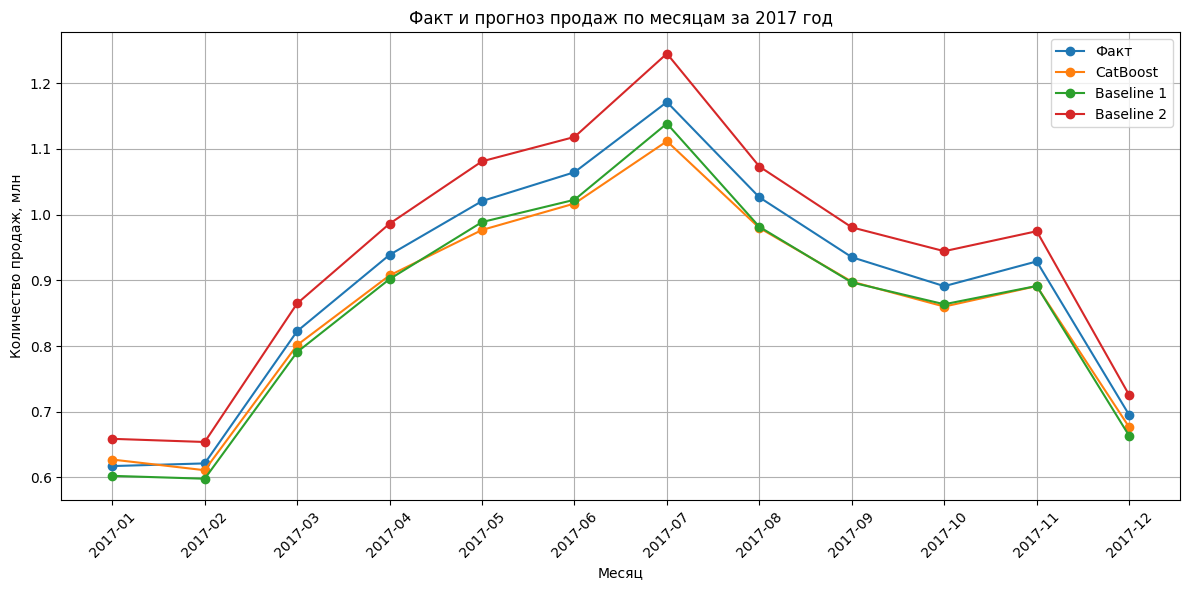

In [265]:
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    fact_2017_group_month['date'].astype(str),
    fact_2017_group_month['Количество_продаж_факт'],
    marker='o',
    label='Факт'
)

plt.plot(
    fact_2017_group_month['date'].astype(str),
    fact_2017_group_month['Прогноз_продаж_CatBoost'],
    marker='o',
    label='CatBoost'
)

plt.plot(
    fact_2017_group_month['date'].astype(str),
    fact_2017_group_month['Прогноз_продаж_Baseline_1'],
    marker='o',
    label='Baseline 1'
)

plt.plot(
    fact_2017_group_month['date'].astype(str),
    fact_2017_group_month['Прогноз_продаж_Baseline_2'],
    marker='o',
    label='Baseline 2'
)

plt.title('Факт и прогноз продаж по месяцам за 2017 год')
plt.xlabel('Месяц')
plt.ylabel('Количество продаж')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x / 1_000_000:.1f}')
)

plt.ylabel('Количество продаж, млн')
plt.savefig(
    'fact_vs_forecast_2017.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


In [214]:
fact_2017['Ошибка_CatBoost_абс'] = abs(fact_2017['sales']- fact_2017['Прогноз_CatBoost'])

In [215]:
error_catboost_by_month = fact_2017.groupby(fact_2017['date'].dt.to_period('M')).agg(Средняя_ошибка_CatBoost = ('Ошибка_CatBoost_абс', 'mean')).reset_index()

In [216]:
error_catboost_by_month

,date,Средняя_ошибка_CatBoost
0,2017-01,4.940767
1,2017-02,5.220979
2,2017-03,5.813406
3,2017-04,6.500178
4,2017-05,6.729796
5,2017-06,7.047543
6,2017-07,7.500572
7,2017-08,6.831787
8,2017-09,6.407202
9,2017-10,6.177796


In [217]:
fact_2017.head()

,date,store,item,sales,Прогноз_CatBoost,data_x,Прогноз_продаж_x,Прогноз_продаж_y,Прогноз_Baseline_2,Ошибка_CatBoost_абс
0,2017-01-01,1,1,19,18.931934,2017-01-01,21,21,23.044856,0.068066
1,2017-01-02,1,1,15,12.607306,2017-01-02,13,13,14.265863,2.392694
2,2017-01-03,1,1,10,14.701907,2017-01-03,12,12,13.168489,4.701907
3,2017-01-04,1,1,16,14.858302,2017-01-04,12,12,13.168489,1.141698
4,2017-01-05,1,1,14,15.686972,2017-01-05,12,12,13.168489,1.686972


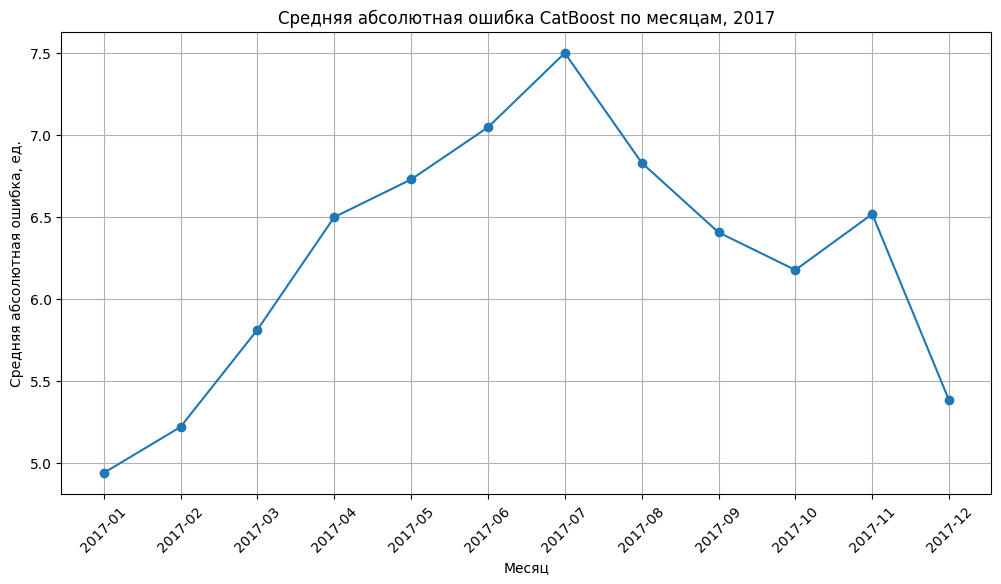

In [266]:
plt.figure(figsize=(12, 6))

plt.plot(
    error_catboost_by_month['date'].astype(str),
    error_catboost_by_month['Средняя_ошибка_CatBoost'],
    marker='o')

plt.title('Средняя абсолютная ошибка CatBoost по месяцам, 2017')
plt.xlabel('Месяц')
plt.ylabel('Средняя абсолютная ошибка, ед.')
plt.xticks(rotation=45)
plt.grid(True)
plt.savefig(
    'catboost_error_by_month_2017.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


<Figure size 640x480 with 0 Axes>